In [100]:
from pandas import read_csv
from datetime import datetime
from pandas import DataFrame
from matplotlib import pyplot
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

# load dataset
def parser(x):
	return datetime.strptime('190'+x, '%Y-%m')

series = read_csv('shampoo.csv', header=0, parse_dates=True, index_col=0, date_parser=parser)
series.index = series.index.to_period('M')

#print(series.head())
#autocorrelation_plot(series)
#series.plot()
#pyplot.show()

/tmp/ipykernel_19832/3371529125.py:14: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series = read_csv('shampoo.csv', header=0, parse_dates=True, index_col=0, date_parser=parser)


In [101]:
# split into train and test sets
X = series.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()

In [102]:
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(5,2,1))
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))

/home/joshmurray/.local/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/joshmurray/.local/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/tmp/ipykernel_19832/3511867902.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f, expected=%f' % (yhat, obs))


predicted=382.658164, expected=342.300000
predicted=327.361685, expected=339.700000
predicted=409.534994, expected=440.400000
predicted=374.709275, expected=315.900000
predicted=402.950253, expected=439.300000
predicted=371.698673, expected=401.300000
predicted=464.930999, expected=437.400000
predicted=413.295702, expected=575.500000
predicted=461.483200, expected=407.600000
predicted=531.942405, expected=682.000000
predicted=467.704138, expected=475.300000
predicted=682.791365, expected=581.300000
predicted=594.708535, expected=646.900000


In [103]:
# evaluate forecasts
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)

Test RMSE: 75.427


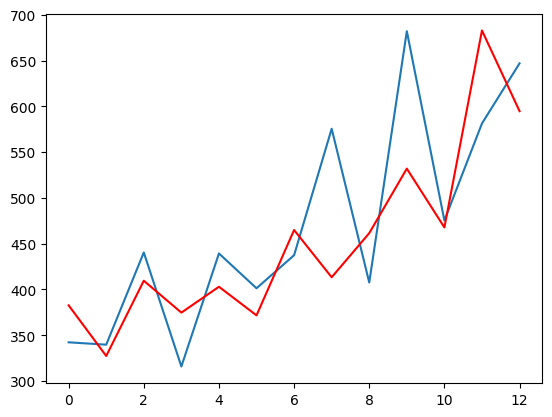

In [104]:
# plot forecasts against actual outcomes
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()